# NorthStar Urban Mobility & Logistics — Exploratory Data Analysis (EDA)

**Module:** Databases and Analytics (CP60056E / CP6CS56E / CP6HA50E)  
**Notebook 1 of the analytical workflow.** This notebook performs the initial exploration of the NorthStar dataset that underpins everything else in the project (SQL-in-R queries, R analytics, Python analysis, MongoDB design, and the demo).

## Purpose of this notebook
1. Load all nine operational CSV tables supplied with the case study (plus `data_dictionary.csv` for field definitions).
2. Profile each table: shape, dtypes, missing values, basic statistics.
3. Identify the **data-quality issues** the README explicitly warns about — inconsistent categorical values, missing values, cross-file relationship problems.
4. Surface **early business signals** (delivery failure rates, complaint patterns, manual overrides, etc.) that will inform the deeper analysis in later notebooks.
5. Produce a **cleaned, harmonised set of DataFrames** ready to be picked up by `02_sql_in_r.ipynb`, `03_r_analytics.ipynb`, `04_python_analysis.ipynb`, and `05_mongodb_design.ipynb`.

## What this notebook is *not*
- It is not the final analysis. It does not answer the executive-level questions (those go in the Python analytics and R notebooks).
- It is not the MongoDB design. It only flags which tables are good candidates for nesting.

## Hypotheses to test downstream (developed from this EDA)
- *Operations director:* poor route allocation and underperforming city hubs → check failure & delay rates **by hub** and **by zone**.
- *Customer experience director:* complaints, missed journeys, and incidents are not joined into a single view → quantify overlap and mismatches between complaint records and delivery/incident status at the order level.
- *Finance director:* certain routes/contracts are unprofitable but invisible in current reports → cost vs. revenue per service type / per zone.
- *Technology director:* relational structure is no longer fit for purpose → assess which files (app_events, complaints histories) are best modelled as MongoDB documents.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
cd drive/MyDrive/Databases and Analytics 2

/content/drive/MyDrive/Databases and Analytics 2


## 1. Setup


In [11]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Point this at the folder containing the nine operational CSVs (+ data_dictionary.csv).
# In Colab: upload northstar_dataset.zip, unzip it, then set:
#   DATA_DIR = Path('/content/northstar_dataset')
DATA_DIR = Path('northstar_dataset')
assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
print("Files available:")
for f in sorted(DATA_DIR.glob('*.csv')):
    print(" ", f.name)

Files available:
  app_events.csv
  complaints.csv
  customers.csv
  data_dictionary.csv
  deliveries.csv
  drivers.csv
  hubs.csv
  incidents.csv
  orders.csv
  vehicles.csv


## 2. Load all tables

We load all nine operational tables into a dictionary (`data_dictionary.csv` is kept separate). Date columns are parsed up-front so downstream analysis does not have to repeat the work.

In [12]:
DATE_COLS = {
    'customers':   ['signup_date'],
    'vehicles':    ['commission_date'],
    'orders':      ['order_created_at'],
    'deliveries':  ['dispatch_time', 'delivery_completed_at'],
    'incidents':   ['reported_at'],
    'complaints':  ['created_at'],
    'app_events':  ['event_timestamp'],
}

tables = {}
for csv in sorted(DATA_DIR.glob('*.csv')):
    name = csv.stem
    if name == 'data_dictionary':
        continue
    parse = DATE_COLS.get(name, None)
    tables[name] = pd.read_csv(csv, parse_dates=parse)

print(f"Loaded {len(tables)} tables\n")
for name, df in tables.items():
    print(f"{name:12s} {df.shape}")

Loaded 9 tables

app_events   (640, 10)
complaints   (320, 10)
customers    (650, 9)
deliveries   (950, 13)
drivers      (170, 8)
hubs         (8, 5)
incidents    (280, 7)
orders       (1250, 11)
vehicles     (120, 8)


### Data dictionary supplied with the dataset

In [13]:
data_dict = pd.read_csv(DATA_DIR / 'data_dictionary.csv')
data_dict

,file_name,record_count,description
0,hubs.csv,8,Operational hubs and control points
1,customers.csv,650,Customer master data with engagement and loyal...
2,drivers.csv,170,Driver workforce data with training and rating...
3,vehicles.csv,120,Fleet asset data including battery and mainten...
4,orders.csv,1250,Service orders across mobility and logistics o...
5,deliveries.csv,950,Operational dispatch and completion outcomes
6,incidents.csv,280,Delivery and asset incident records
7,complaints.csv,320,Customer complaints and compensation handling
8,app_events.csv,640,Digital platform events suitable for MongoDB r...


## 3. Profile each table

For every table we look at:
- **head()** — a sample of records
- **dtypes** — confirm types are sensible
- **missing values** — count and percentage
- **describe()** — basic statistics for numeric columns

This is where the data-quality issues start to surface.

In [14]:
def profile(name, df):
    print(f"{'='*70}\n  {name.upper()}  —  shape {df.shape}\n{'='*70}")
    display(df.head(3))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss):
        miss_pct = (miss / len(df) * 100).round(1)
        print(pd.concat([miss.rename('count'), miss_pct.rename('pct')], axis=1))
    else:
        print("  none")
    print("\nNumeric summary:")
    print(df.describe(include='number').round(2))
    print()

### 3.1 `hubs`

In [15]:
profile('hubs', tables['hubs'])

  HUBS  —  shape (8, 5)


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74



Dtypes:
hub_id            object
hub_name          object
zone              object
hub_type          object
capacity_score     int64
dtype: object

Missing values:
  none

Numeric summary:
       capacity_score
count            8.00
mean            73.88
std              8.41
min             63.00
25%             68.25
50%             72.50
75%             79.00
max             88.00



### 3.2 `customers`

In [16]:
profile('customers', tables['customers'])

  CUSTOMERS  —  shape (650, 9)


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active



Dtypes:
customer_id                     object
age                              int64
home_zone                       object
customer_type                   object
signup_date             datetime64[ns]
loyalty_score                  float64
app_engagement_score           float64
preferred_channel               object
account_status                  object
dtype: object

Missing values:
                   count  pct
loyalty_score         20  3.1
preferred_channel     13  2.0

Numeric summary:
          age  loyalty_score  app_engagement_score
count  650.00         630.00                650.00
mean    46.74          59.69                 58.13
std     17.45          16.12                 18.92
min     18.00          13.10                  1.00
25%     32.00          49.00                 45.38
50%     46.00          59.60                 59.00
75%     62.00          70.45                 72.00
max     78.00          99.00                100.00



### 3.3 `drivers`

In [17]:
profile('drivers', tables['drivers'])

  DRIVERS  —  shape (170, 8)


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
1,D002,Central,FullTime,4,42.4,3.94,Evening,1
2,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1



Dtypes:
driver_id            object
base_zone            object
employment_type      object
years_experience      int64
training_score      float64
driver_rating       float64
shift_preference     object
active_flag           int64
dtype: object

Missing values:
                count  pct
training_score      7  4.1

Numeric summary:
       years_experience  training_score  driver_rating  active_flag
count            170.00          163.00         170.00       170.00
mean               8.22           74.91           4.17         0.95
std                4.11           11.21           0.41         0.22
min                1.00           40.60           3.15         0.00
25%                5.00           68.55           3.90         1.00
50%                8.50           75.20           4.18         1.00
75%               11.75           82.75           4.48         1.00
max               15.00           99.00           5.00         1.00



### 3.4 `vehicles`

In [18]:
profile('vehicles', tables['vehicles'])

  VEHICLES  —  shape (120, 8)


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1



Dtypes:
vehicle_id                    object
vehicle_type                  object
assigned_zone                 object
commission_date       datetime64[ns]
battery_health_pct           float64
odometer_km                    int64
maintenance_status            object
telematics_version            object
dtype: object

Missing values:
                    count  pct
battery_health_pct      4  3.3

Numeric summary:
       battery_health_pct  odometer_km
count              116.00       120.00
mean                76.79    115739.47
std                 12.70     58256.96
min                 42.00     15138.00
25%                 68.20     67927.50
50%                 78.05    112293.00
75%                 85.78    160087.50
max                100.00    219359.00



### 3.5 `orders`

In [19]:
profile('orders', tables['orders'])

  ORDERS  —  shape (1250, 11)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0



Dtypes:
order_id                         object
customer_id                      object
service_type                     object
order_created_at         datetime64[ns]
promised_window_hours             int64
pickup_zone                      object
dropoff_zone                     object
priority_level                   object
order_value                     float64
booking_channel                  object
special_handling_flag             int64
dtype: object

Missing values:
                 count  pct
booking_channel     25  2.0

Numeric summary:
       promised_window_hours  order_value  special_handling_flag
count                1250.00      1250.00                1250.00
mean                    7.62        91.05                   0.19
std                     7.06        60.92                   0.39
min                     1.00         2.04                   0.00
25%                     4.00        47.92                   0.00
50%                     6.00        76.53               

### 3.6 `deliveries`

In [20]:
profile('deliveries', tables['deliveries'])

  DELIVERIES  —  shape (950, 13)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51



Dtypes:
delivery_id                              object
order_id                                 object
driver_id                                object
vehicle_id                               object
hub_id                                   object
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                          object
route_distance_km                       float64
manual_route_override_count               int64
proof_of_completion_missing               int64
customer_rating_post_delivery           float64
fuel_or_charge_cost                     float64
dtype: object

Missing values:
                               count  pct
delivery_completed_at             19  2.0
customer_rating_post_delivery     14  1.5

Numeric summary:
       route_distance_km  manual_route_override_count  proof_of_completion_missing  customer_rating_post_delivery  fuel_or_charge_cost
count             950.00                       950.00    

### 3.7 `incidents`

In [21]:
profile('incidents', tables['incidents'])

  INCIDENTS  —  shape (280, 7)


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0



Dtypes:
incident_id                  object
delivery_id                  object
incident_type                object
reported_at          datetime64[ns]
severity                     object
resolution_status            object
resolved_hours              float64
dtype: object

Missing values:
                count  pct
resolved_hours     17  6.1

Numeric summary:
       resolved_hours
count          263.00
mean            12.01
std              7.75
min              0.00
25%              5.15
50%             11.50
75%             17.95
max             41.70



### 3.8 `complaints`

In [22]:
profile('complaints', tables['complaints'])

  COMPLAINTS  —  shape (320, 10)


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41



Dtypes:
complaint_id                   object
customer_id                    object
order_id                       object
complaint_type                 object
channel                        object
severity                       object
created_at             datetime64[ns]
status                         object
resolution_days                 int64
compensation_amount           float64
dtype: object

Missing values:
                     count  pct
compensation_amount     16  5.0

Numeric summary:
       resolution_days  compensation_amount
count           320.00               304.00
mean              7.93                20.26
std               5.21                15.00
min               1.00                 0.00
25%               3.75                 8.82
50%               7.00                18.40
75%              11.00                29.14
max              25.00                61.85



### 3.9 `app_events`

In [23]:
profile('app_events', tables['app_events'])

  APP_EVENTS  —  shape (640, 10)


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1



Dtypes:
event_id                   object
customer_id                object
order_id                   object
event_timestamp    datetime64[ns]
event_type                 object
session_id                 object
device_type                object
zone_context               object
api_latency_ms              int64
success_flag                int64
dtype: object

Missing values:
          count   pct
order_id    144  22.5

Numeric summary:
       api_latency_ms  success_flag
count          640.00        640.00
mean           465.67          0.94
std            271.63          0.24
min             60.00          0.00
25%            278.75          1.00
50%            432.50          1.00
75%            609.00          1.00
max           1701.00          1.00



## 4. Data quality issues

The dataset README states explicitly:
> *This dataset includes inconsistent categorical values, missing values, cross-file relationships, hidden operational delay/failure patterns…*

We now characterise these issues so they can be fixed once, centrally, before downstream analysis.

### 4.1 Inconsistent zone values

`zone` (and its aliases `home_zone`, `base_zone`, `assigned_zone`, `pickup_zone`, `dropoff_zone`, `zone_context`) appears in six different tables. Even within a single column the spelling and casing are inconsistent (`North`, `NORTH`, `north`, `Riverside`, `RiverSide`, `Central`, `CENTRAL`, `Ctr`, ...). This will break any join, groupby, or aggregation that uses zone as a key.

In [24]:
zone_cols = {
    'customers':  'home_zone',
    'drivers':    'base_zone',
    'vehicles':   'assigned_zone',
    'orders':     'pickup_zone',   # also dropoff_zone
    'hubs':       'zone',
    'app_events': 'zone_context',
}
for tbl, col in zone_cols.items():
    print(f"{tbl}.{col}: {sorted(tables[tbl][col].dropna().unique().tolist())}")

customers.home_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
drivers.base_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
vehicles.assigned_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
orders.pickup_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
hubs.zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
app_events.zone_context: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


**Diagnosis.** Three distinct issues are present:
1. **Case variations** — `North`, `NORTH`, `north` all refer to the same zone.
2. **Abbreviation** — `Ctr` is an abbreviation of `Central`.
3. **Camel-case inconsistency** — `Riverside` vs `RiverSide`.

We standardise to title-case canonical names. The `dropoff_zone` column in `orders` has the same issue.

In [25]:
ZONE_CANONICAL = {
    'airport': 'Airport',
    'central': 'Central',
    'ctr':     'Central',
    'east':    'East',
    'north':   'North',
    'riverside': 'Riverside',
    'south':   'South',
    'west':    'West',
}

def clean_zone(s):
    if pd.isna(s):
        return s
    return ZONE_CANONICAL.get(str(s).strip().lower(), str(s).strip().title())

# Apply to every zone column we found
tables['customers']['home_zone']        = tables['customers']['home_zone'].apply(clean_zone)
tables['drivers']['base_zone']          = tables['drivers']['base_zone'].apply(clean_zone)
tables['vehicles']['assigned_zone']     = tables['vehicles']['assigned_zone'].apply(clean_zone)
tables['orders']['pickup_zone']         = tables['orders']['pickup_zone'].apply(clean_zone)
tables['orders']['dropoff_zone']        = tables['orders']['dropoff_zone'].apply(clean_zone)
tables['hubs']['zone']                  = tables['hubs']['zone'].apply(clean_zone)
tables['app_events']['zone_context']    = tables['app_events']['zone_context'].apply(clean_zone)

# Verify
print("After cleaning:")
for tbl, col in zone_cols.items():
    print(f"  {tbl}.{col}: {sorted(tables[tbl][col].dropna().unique().tolist())}")

After cleaning:
  customers.home_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  drivers.base_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  vehicles.assigned_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  orders.pickup_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  hubs.zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  app_events.zone_context: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


### 4.2 Missing values across all tables

Summary of missingness after zone cleaning.

In [26]:
miss_summary = []
for name, df in tables.items():
    for col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss:
            miss_summary.append({
                'table': name,
                'column': col,
                'missing': int(n_miss),
                'pct': round(n_miss/len(df)*100, 1),
            })
miss_df = pd.DataFrame(miss_summary).sort_values('pct', ascending=False)
miss_df

,table,column,missing,pct
0,app_events,order_id,144,22.5
7,incidents,resolved_hours,17,6.1
1,complaints,compensation_amount,16,5.0
6,drivers,training_score,7,4.1
9,vehicles,battery_health_pct,4,3.3
2,customers,loyalty_score,20,3.1
3,customers,preferred_channel,13,2.0
4,deliveries,delivery_completed_at,19,2.0
8,orders,booking_channel,25,2.0
5,deliveries,customer_rating_post_delivery,14,1.5


**Interpretation of each gap:**

| Missing field | What it means for the business |
|---|---|
| `app_events.order_id` (22% missing) | Many app interactions (eta_refresh, search_route, chat) are *not* tied to a specific order — they are pre-booking activity. Expected, not an error. |
| `customers.loyalty_score` (3%) | A handful of customers have no loyalty score recorded yet. Impute (e.g., mean per customer_type) or drop in models that need it. |
| `customers.preferred_channel` (2%) | Missing channel — could be encoded as 'Unknown' rather than dropped. |
| `drivers.training_score` (4%) | Driver training gap — worth flagging operationally (these drivers may be untrained). |
| `vehicles.battery_health_pct` (3%) | Missing values appear on **EV and Hybrid** rows only (see cross-check below) — likely incomplete telematics, not “non-EV = N/A”. |
| `orders.booking_channel` (2%) | Channel not captured — impute as 'Unknown'. |
| `deliveries.delivery_completed_at` (2%) | Missing completion timestamps are **not** confined to Failed deliveries (OnTime 12, Delayed 4, Failed 3 of 19). Treat as mixed data-quality / logging gaps. See cross-check below. |
| `deliveries.customer_rating_post_delivery` (1.5%) | Customer never rated — common in real life. |
| `incidents.resolved_hours` (6%) | Incidents that are still open / not resolved — by definition have no resolved time. |
| `complaints.compensation_amount` (5%) | Complaints that received no compensation. |


In [27]:
# Cross-check: missing delivery_completed_at by outcome; battery_health by vehicle_type
deliv = tables['deliveries']
print("delivery_completed_at NaN by status:")
print(deliv.groupby('delivery_status')['delivery_completed_at'].apply(lambda s: s.isna().sum()))
print()
veh = tables['vehicles']
print("battery_health_pct NaN by vehicle_type:")
print(veh.groupby('vehicle_type')['battery_health_pct'].apply(lambda s: s.isna().sum()))

delivery_completed_at NaN by status:
delivery_status
Delayed     4
Failed      3
OnTime     12
Name: delivery_completed_at, dtype: int64

battery_health_pct NaN by vehicle_type:
vehicle_type
CargoVan    0
Diesel      0
EV          2
Hybrid      2
Name: battery_health_pct, dtype: int64


**Cross-check (updates the table above).** Most missing `delivery_completed_at` values are **OnTime** (12/19), not Failed-only. Missing `battery_health_pct` affects **EV (2)** and **Hybrid (2)** only; Diesel and CargoVan have none.


### 4.3 Referential integrity (cross-file relationships)

We check the foreign-key style relationships between tables to make sure joins downstream will be safe.

In [28]:
def fk_check(child_df, child_col, parent_df, parent_col, label):
    child_values = child_df[child_col].dropna()
    missing = ~child_values.isin(parent_df[parent_col])
    n = missing.sum()
    print(f"{label}: {n} broken references ({n/len(child_values)*100:.1f}%)")

print("--- Referential integrity ---")
fk_check(tables['deliveries'], 'order_id',     tables['orders'],    'order_id',    'deliveries → orders')
fk_check(tables['deliveries'], 'driver_id',    tables['drivers'],   'driver_id',   'deliveries → drivers')
fk_check(tables['deliveries'], 'vehicle_id',   tables['vehicles'],  'vehicle_id',  'deliveries → vehicles')
fk_check(tables['deliveries'], 'hub_id',       tables['hubs'],      'hub_id',      'deliveries → hubs')
fk_check(tables['complaints'], 'customer_id',  tables['customers'], 'customer_id', 'complaints → customers')
fk_check(tables['complaints'], 'order_id',     tables['orders'],    'order_id',    'complaints → orders')
fk_check(tables['incidents'],  'delivery_id',  tables['deliveries'],'delivery_id', 'incidents → deliveries')
fk_check(tables['orders'],     'customer_id',  tables['customers'], 'customer_id', 'orders → customers')
fk_check(tables['app_events'], 'customer_id',  tables['customers'], 'customer_id', 'app_events → customers')
fk_check(tables['app_events'], 'order_id',     tables['orders'],    'order_id',    'app_events → orders')

--- Referential integrity ---
deliveries → orders: 0 broken references (0.0%)
deliveries → drivers: 0 broken references (0.0%)
deliveries → vehicles: 0 broken references (0.0%)
deliveries → hubs: 0 broken references (0.0%)
complaints → customers: 0 broken references (0.0%)
complaints → orders: 0 broken references (0.0%)
incidents → deliveries: 0 broken references (0.0%)
orders → customers: 0 broken references (0.0%)
app_events → customers: 0 broken references (0.0%)
app_events → orders: 0 broken references (0.0%)


### 4.4 Orders without deliveries — a real business gap

The case study highlights that some customers "report late arrival or failed service, yet their transactions appear 'completed' in one system and 'exception-handled' in another." We check the inverse: orders that **never produced a delivery record at all**.

In [29]:
orders_with_delivery = tables['deliveries']['order_id'].unique()
no_delivery_mask = ~tables['orders']['order_id'].isin(orders_with_delivery)
n_missing = no_delivery_mask.sum()
print(f"Orders with NO matching delivery record: {n_missing} / {len(tables['orders'])} "
      f"({n_missing/len(tables['orders'])*100:.1f}%)")

# Are these concentrated in any service_type / zone / channel?
missing_orders = tables['orders'][no_delivery_mask]
print("\nBy service_type:")
print(missing_orders['service_type'].value_counts(normalize=True).round(3))
print("\nBy pickup_zone:")
print(missing_orders['pickup_zone'].value_counts(normalize=True).round(3))
print("\nBy booking_channel:")
print(missing_orders['booking_channel'].value_counts(normalize=True, dropna=False).round(3))

Orders with NO matching delivery record: 300 / 1250 (24.0%)

By service_type:
service_type
Passenger    0.263
Parcel       0.260
Retail       0.243
Business     0.130
Medical      0.103
Name: proportion, dtype: float64

By pickup_zone:
pickup_zone
Central      0.213
East         0.170
South        0.140
West         0.137
North        0.130
Riverside    0.107
Airport      0.103
Name: proportion, dtype: float64

By booking_channel:
booking_channel
App      0.433
Web      0.247
Phone    0.233
API      0.073
NaN      0.013
Name: proportion, dtype: float64


**This is a finding worth raising.** ~24% of orders have no corresponding delivery record. Whether these are cancellations, lost data, or 'completed in one system and exception-handled in another' is the kind of fragmentation the case study points to. Flag for the final report.

## 5. Early business signals

These are the patterns that will be developed further in the analytics notebooks. Surfacing them now keeps the downstream work focused on real issues rather than fishing expeditions.

### 5.1 Delivery outcomes — failure & delay rates

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Failure rate:  13.9%
Delay rate:    21.3%
On-time rate:  64.8%


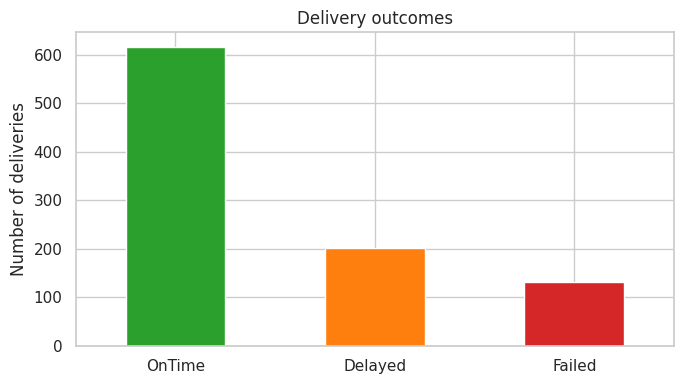

In [30]:
deliv = tables['deliveries']
status_counts = deliv['delivery_status'].value_counts()
print(status_counts)
print(f"\nFailure rate:  {(deliv['delivery_status']=='Failed').mean()*100:.1f}%")
print(f"Delay rate:    {(deliv['delivery_status']=='Delayed').mean()*100:.1f}%")
print(f"On-time rate:  {(deliv['delivery_status']=='OnTime').mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
status_counts.plot(kind='bar', ax=ax, color=['#2ca02c', '#ff7f0e', '#d62728'])
ax.set_title("Delivery outcomes")
ax.set_ylabel("Number of deliveries")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Delivery outcomes **by hub** — does the operations director's hypothesis hold?

In [31]:
hubs = tables['hubs']
deliv_hub = deliv.merge(hubs[['hub_id', 'hub_name', 'zone', 'hub_type']], on='hub_id')

hub_perf = (deliv_hub.groupby(['hub_id', 'hub_name', 'zone', 'hub_type'])
                    .agg(n=('delivery_id', 'count'),
                         fail_rate=('delivery_status', lambda s: (s=='Failed').mean()),
                         delay_rate=('delivery_status', lambda s: (s=='Delayed').mean()),
                         avg_override=('manual_route_override_count', 'mean'),
                         avg_rating=('customer_rating_post_delivery', 'mean'))
                    .round(3)
                    .sort_values('fail_rate', ascending=False))
hub_perf

,,,,n,fail_rate,delay_rate,avg_override,avg_rating
hub_id,hub_name,zone,hub_type,,,,,
H08,Midtown Relay,Central,Charging,128,0.203,0.172,1.109,3.885
H05,Central Core,Central,Control,115,0.200,0.217,0.948,3.670
H06,Airport Hub,Airport,Dispatch,104,0.144,0.260,0.913,3.882
H04,West Gate,West,Dispatch,127,0.126,0.220,0.874,3.915
H01,North Exchange,North,Dispatch,136,0.125,0.191,1.029,3.841
H07,Riverside Hub,Riverside,Warehouse,115,0.122,0.217,1.052,3.882
H02,South Link,South,Dispatch,106,0.094,0.245,0.915,3.951
H03,East Dock,East,Warehouse,119,0.092,0.193,0.891,3.896


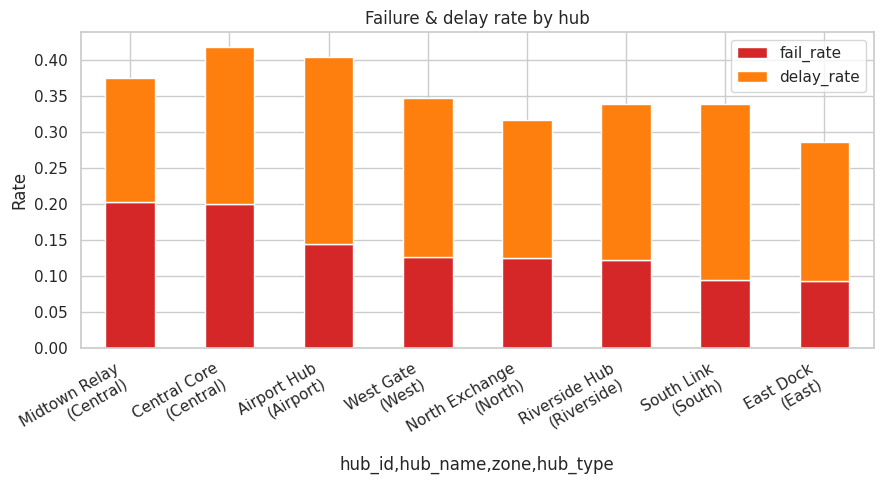

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
hub_perf[['fail_rate', 'delay_rate']].plot(kind='bar', stacked=True, ax=ax,
                                            color=['#d62728', '#ff7f0e'])
ax.set_title("Failure & delay rate by hub")
ax.set_ylabel("Rate")
ax.set_xticklabels([f"{idx[1]}\n({idx[2]})" for idx in hub_perf.index], rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Hub takeaway.** Failure and delay rates **both vary by hub**, but they do not always move together. Central hubs (e.g. H08 Midtown Relay, H05 Central Core) show the highest **failure** rates (~20%). **H06 Airport Hub** stands out for **delay** (~26%) with a more moderate failure rate (~14%). That partially supports the operations director’s concern, but a single “worst hub” ranking depends on whether you prioritise failures, delays, or both.


### 5.3 Manual route overrides — what the drivers are doing

Manual route override count distribution:
manual_route_override_count
0    399
1    310
2    153
3     57
4     23
5      7
7      1
Name: count, dtype: int64

Overrides by outcome:
                 mean  median  max
delivery_status                   
Delayed          1.07     1.0    5
Failed           1.04     1.0    4
OnTime           0.92     1.0    7


/tmp/ipykernel_951/1722896290.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deliv, x='delivery_status', y='manual_route_override_count',


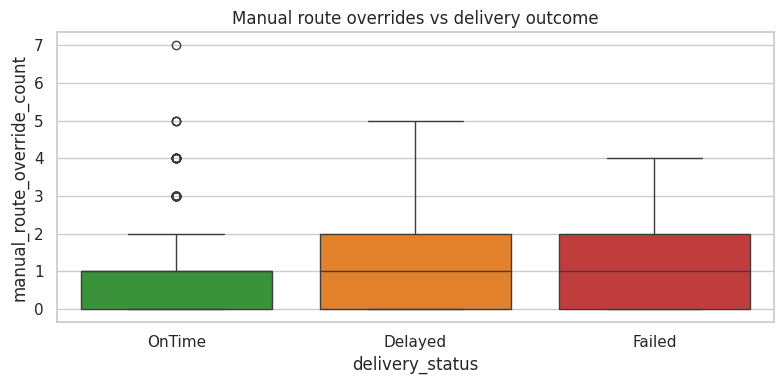

In [33]:
print("Manual route override count distribution:")
print(deliv['manual_route_override_count'].value_counts().sort_index())

# Does override count correlate with delivery outcome?
override_vs_outcome = (deliv.groupby('delivery_status')['manual_route_override_count']
                            .agg(['mean', 'median', 'max']).round(2))
print("\nOverrides by outcome:")
print(override_vs_outcome)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=deliv, x='delivery_status', y='manual_route_override_count',
            order=['OnTime', 'Delayed', 'Failed'], ax=ax,
            palette=['#2ca02c', '#ff7f0e', '#d62728'])
ax.set_title("Manual route overrides vs delivery outcome")
plt.tight_layout()
plt.show()

**Override takeaway.** Mean `manual_route_override_count` is only slightly higher for poor outcomes (OnTime **0.92**, Delayed **1.07**, Failed **1.04**). Overrides are **not** a strong discriminator of failure; **Delayed** deliveries average the most overrides, not Failed. Any link to route problems is weak in this snapshot — deeper analysis in later notebooks can combine overrides with distance and hub.


### 5.4 Complaints — volume, type, channel, resolution

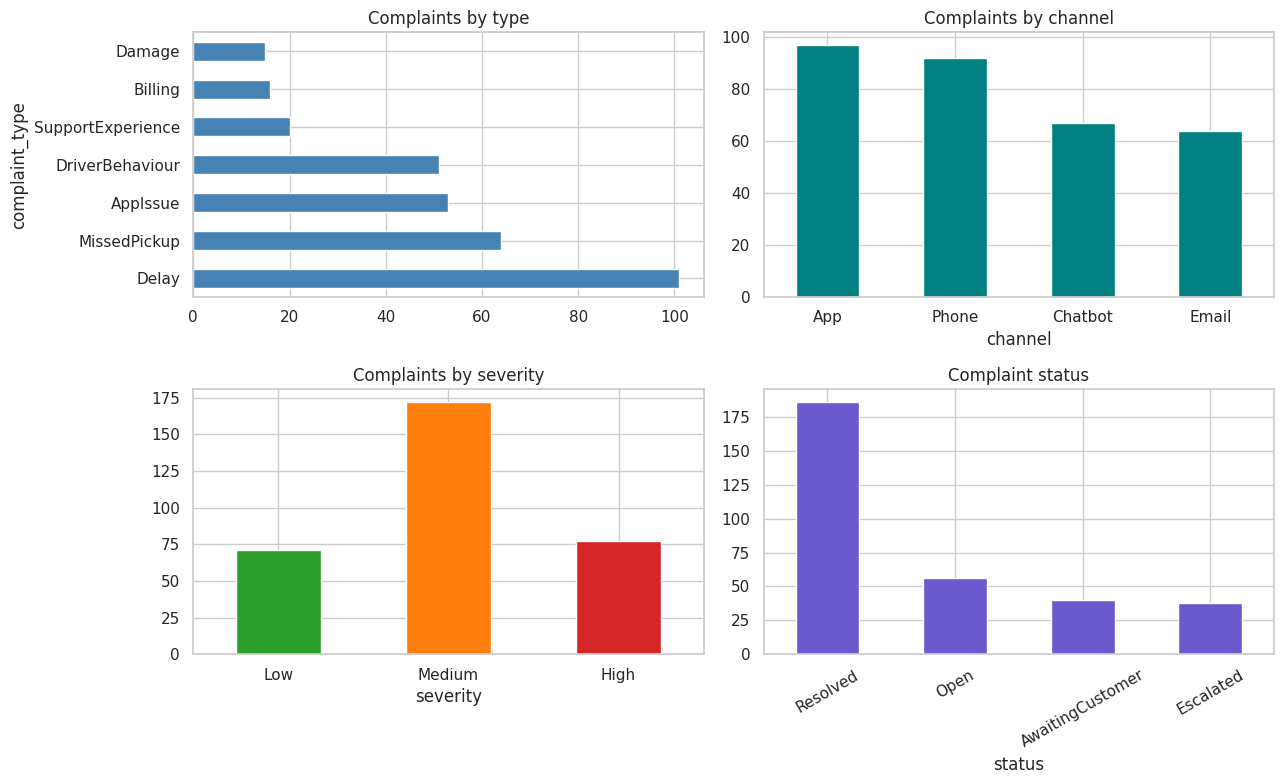


Total compensation paid: £6,158.19
Average compensation:   £20.26
Average resolution time: 7.9 days


In [34]:
compl = tables['complaints']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
compl['complaint_type'].value_counts().plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Complaints by type")

compl['channel'].value_counts().plot(kind='bar', ax=axes[0, 1], color='teal')
axes[0, 1].set_title("Complaints by channel")
axes[0, 1].tick_params(axis='x', rotation=0)

compl['severity'].value_counts().reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', ax=axes[1, 0], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[1, 0].set_title("Complaints by severity")
axes[1, 0].tick_params(axis='x', rotation=0)

compl['status'].value_counts().plot(kind='bar', ax=axes[1, 1], color='slateblue')
axes[1, 1].set_title("Complaint status")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\nTotal compensation paid: £{compl['compensation_amount'].sum():,.2f}")
print(f"Average compensation:   £{compl['compensation_amount'].mean():.2f}")
print(f"Average resolution time: {compl['resolution_days'].mean():.1f} days")

### 5.5 Incidents — the operational side

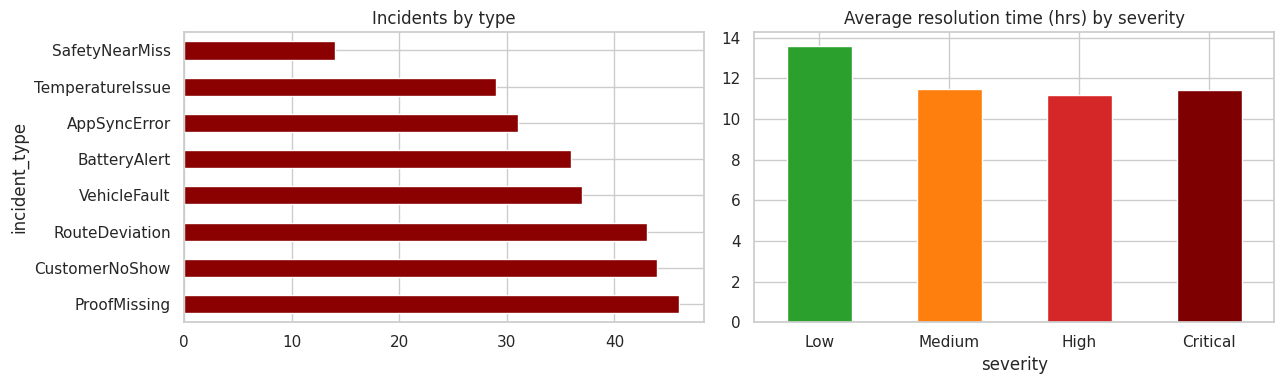

In [35]:
inc = tables['incidents']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
inc['incident_type'].value_counts().plot(kind='barh', ax=axes[0], color='darkred')
axes[0].set_title("Incidents by type")

inc.groupby('severity')['resolved_hours'].mean().reindex(['Low','Medium','High','Critical']).plot(
    kind='bar', ax=axes[1], color=['#2ca02c','#ff7f0e','#d62728','#7f0000'])
axes[1].set_title("Average resolution time (hrs) by severity")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5.6 The 'fragmented view' problem in action

The customer experience director argued that complaints, missed journeys, failed deliveries and incidents are not joined. Let's quantify the overlap.

In [36]:
# Orders that have a complaint
orders_with_complaint = set(compl['order_id'].dropna().unique())
# Orders with a failed/delayed delivery
bad_deliv_orders = set(deliv.loc[deliv['delivery_status'].isin(['Failed','Delayed']), 'order_id'])
# Orders with an incident
inc_deliv = inc.merge(deliv[['delivery_id','order_id']], on='delivery_id')
orders_with_incident = set(inc_deliv['order_id'].dropna().unique())

all_problem_orders = orders_with_complaint | bad_deliv_orders | orders_with_incident

print(f"Orders with a complaint:                       {len(orders_with_complaint)}")
print(f"Orders with a failed/delayed delivery:         {len(bad_deliv_orders)}")
print(f"Orders with at least one incident:             {len(orders_with_incident)}")
print(f"Orders touched by ANY of the three:            {len(all_problem_orders)}")
print(f"Orders touched by ALL THREE:                   "
      f"{len(orders_with_complaint & bad_deliv_orders & orders_with_incident)}")
print(f"\nComplaints whose underlying delivery is NOT recorded as Failed/Delayed: "
      f"{len(orders_with_complaint - bad_deliv_orders)}")

Orders with a complaint:                       285
Orders with a failed/delayed delivery:         334
Orders with at least one incident:             248
Orders touched by ANY of the three:            681
Orders touched by ALL THREE:                   18

Complaints whose underlying delivery is NOT recorded as Failed/Delayed: 207


**Finding for the report.** A non-trivial number of complaint orders have a delivery status of *OnTime*. That is exactly the fragmentation the case study describes — *"customers repeatedly report late arrival or failed service, yet their transactions appear 'completed' in one system and 'exception-handled' in another."*

### 5.7 App events — candidate for MongoDB

In [37]:
ae = tables['app_events']
print("Event types:")
print(ae['event_type'].value_counts())
print("\nDevice types:")
print(ae['device_type'].value_counts())
print(f"\nSuccess flag (1=success): mean = {ae['success_flag'].mean():.3f}")
print(f"API latency (ms):  mean = {ae['api_latency_ms'].mean():.0f}, "
      f"p95 = {ae['api_latency_ms'].quantile(0.95):.0f}")
print(f"\nDistinct sessions: {ae['session_id'].nunique()}")
print(f"Avg events per session: {len(ae)/ae['session_id'].nunique():.1f}")
print(f"Events with no order_id: {ae['order_id'].isna().sum()} "
      f"({ae['order_id'].isna().mean()*100:.0f}%)")

# Failure rate by event type — is anything breaking?
print("\nSuccess rate by event type:")
print(ae.groupby('event_type')['success_flag'].mean().sort_values().round(3))

Event types:
event_type
track_order                    138
eta_refresh                    105
search_route                    99
chat_opened                     88
delivery_instruction_update     75
payment_retry                   69
chat_escalated                  38
cancel_attempt                  28
Name: count, dtype: int64

Device types:
device_type
Android    315
iOS        233
Web         92
Name: count, dtype: int64

Success flag (1=success): mean = 0.941
API latency (ms):  mean = 466, p95 = 897

Distinct sessions: 637
Avg events per session: 1.0
Events with no order_id: 144 (22%)

Success rate by event type:
event_type
chat_escalated                 0.500
payment_retry                  0.725
chat_opened                    1.000
cancel_attempt                 1.000
delivery_instruction_update    1.000
eta_refresh                    1.000
search_route                   1.000
track_order                    1.000
Name: success_flag, dtype: float64


**Why this is the prime MongoDB candidate.** App events are session-based, semi-structured, and naturally nest under a customer or an order. The schema in the relational form (one flat row per event) is awkward for queries like *"show me everything that happened in session S19847"* or *"give me the complete app interaction history for customer C0488"*. In MongoDB we can store one document per session (or per customer) with an array of nested event records — exactly the shape the case study describes.

### 5.8 Temporal patterns — is the dataset stable over time?

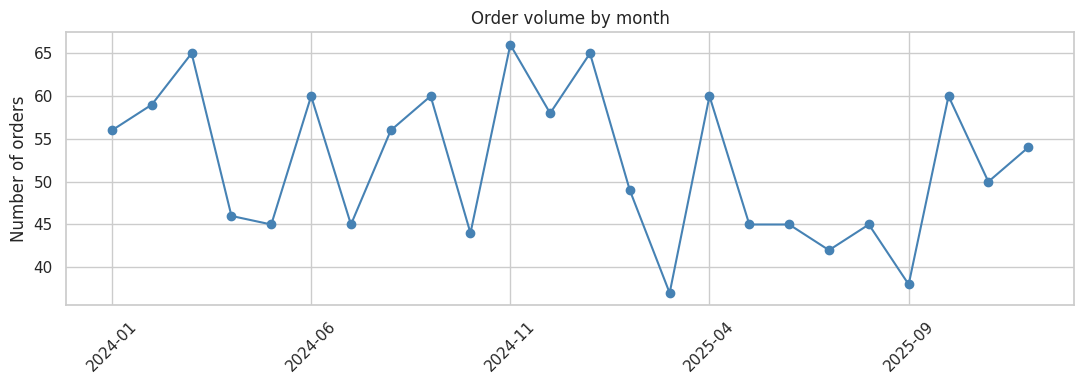


Date range: 2024-01-01 01:29:00 → 2025-12-31 14:49:00


In [38]:
# Orders over time
orders_t = tables['orders'].copy()
orders_t['month'] = orders_t['order_created_at'].dt.to_period('M').astype(str)
monthly = orders_t.groupby('month').size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker='o', color='steelblue')
ax.set_title("Order volume by month")
ax.set_ylabel("Number of orders")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nDate range: {orders_t['order_created_at'].min()} → {orders_t['order_created_at'].max()}")

### 5.9 Correlations among numeric delivery features

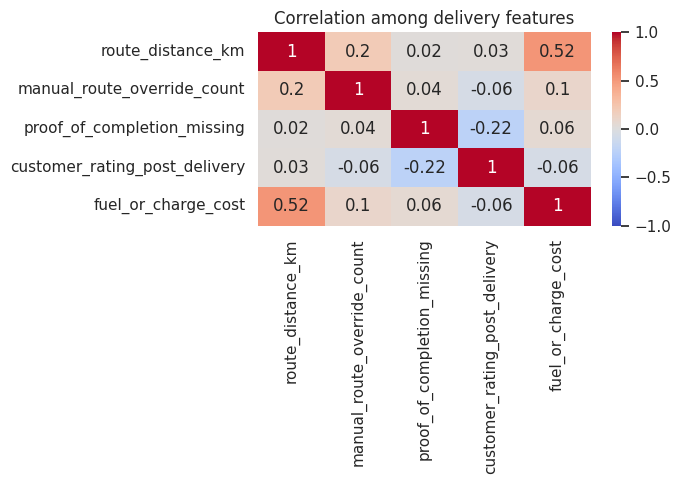

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
route_distance_km,1.00,0.20,0.02,0.03,0.52
manual_route_override_count,0.20,1.00,0.04,-0.06,0.10
proof_of_completion_missing,0.02,0.04,1.00,-0.22,0.06
customer_rating_post_delivery,0.03,-0.06,-0.22,1.00,-0.06
fuel_or_charge_cost,0.52,0.10,0.06,-0.06,1.00


In [39]:
num_cols = ['route_distance_km', 'manual_route_override_count',
            'proof_of_completion_missing', 'customer_rating_post_delivery',
            'fuel_or_charge_cost']
corr = deliv[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation among delivery features")
plt.tight_layout()
plt.show()

corr

## 6. Summary of EDA findings

### Data quality
- **Zone fields** were inconsistent across six tables (case, abbreviation, camel-casing). All harmonised to canonical title-case.
- **Missing values** are limited and largely explainable: mixed missing `delivery_completed_at` (mostly OnTime rows), EV/Hybrid-only gaps in `battery_health_pct`, open incidents with no `resolved_hours`, complaints with no compensation, ~22% of app events not linked to an order (pre-booking activity).
- **Referential integrity** for the main keys (`order_id`, `customer_id`, `delivery_id`, `driver_id`, `vehicle_id`, `hub_id`) is intact.
- **~24% of orders have no delivery record at all** — a real fragmentation problem worth raising with NorthStar.

### Early business signals (for the analytics notebooks to develop)
| Director's hypothesis | What the data shows so far |
|---|---|
| Operations: poor hubs / routes | Failure and delay rates vary **by hub** (Central hubs worst on failure; Airport worst on delay). Manual overrides are only **slightly** higher for Delayed/Failed than OnTime (means ~1.07 / 1.04 vs 0.92) — not a strong failure signal on their own. |
| Customer experience: fragmented view | A subset of complaint-bearing orders have an `OnTime` delivery status — direct evidence that complaint, delivery and incident data are not telling a single story. |
| Finance: hidden unprofitable routes | Fuel/charge cost data is available; combining with route distance and rating gives a basis for the profitability question in the Python notebook. |
| Technology: relational not fit for purpose | `app_events` is highly session-oriented, partly orphaned from orders, and naturally nests — the prime MongoDB candidate. `complaints` with their channel/status history is the second. |

### Tables that should stay relational
`hubs`, `vehicles`, `drivers`, `customers`, `orders`, `deliveries` — all have stable, regular structure ideal for SQL queries and joins (the SQL-in-R notebook).

### Tables that should move to MongoDB
- **`app_events`** → one document per session, embedded array of events.
- **`complaints`** → one document per complaint with embedded resolution history / messages (the case study refers to "long sequences of messages, repeated status changes, attachments, escalation notes").
- Possibly an **integrated case-history document** per customer-order tying together delivery, complaint, and incident — this is what the board explicitly wants ("an integrated operational view of customers, journeys, exceptions, complaints, and service events without the rigidity that currently limits reporting").

## 7. Save cleaned tables for downstream notebooks

In [40]:
OUT = Path('cleaned_data')
OUT.mkdir(exist_ok=True)
for name, df in tables.items():
    df.to_csv(OUT / f'{name}.csv', index=False)
    print(f"Saved {name}.csv  ({df.shape[0]} rows)")

Saved app_events.csv  (640 rows)
Saved complaints.csv  (320 rows)
Saved customers.csv  (650 rows)
Saved deliveries.csv  (950 rows)
Saved drivers.csv  (170 rows)
Saved hubs.csv  (8 rows)
Saved incidents.csv  (280 rows)
Saved orders.csv  (1250 rows)
Saved vehicles.csv  (120 rows)


---

## Next steps

- **`02_sql_in_r.ipynb`** — load the cleaned CSVs in R, use `sqldf` to answer the operational questions (hub performance, route profitability, complaint hotspots).
- **`03_r_analytics.ipynb`** — ggplot visualisations, summary statistics, linear regression of customer rating / delivery success against route/driver/hub features.
- **`04_python_analysis.ipynb`** — deeper Pandas/NumPy analysis, feature engineering, additional visualisations.
- **`05_mongodb_design.ipynb`** — design the document schema, load `app_events` and `complaints` into MongoDB Atlas via `pymongo`, demonstrate CRUD.
- **`06_indexing.ipynb`** — create indexes, run `explain()`, measure before/after performance.
